
# Notebook 1: Vehicle Classification with Classical ML Algorithms
# Dataset: VehicleClassifier from HuggingFace

### 1. Import Libraries

In [1]:
!pip install mpld3

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')
import mpld3
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.transform import factor_cmap
from mpl_toolkits.mplot3d import Axes3D

# 2. Enable interactive matplotlib

In [3]:
!pip install ipympl

In [4]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

In [6]:
%matplotlib widget

### 3. Load and Explore Dataset

In [7]:
# Load dataset from HuggingFace
from datasets import load_dataset

# Load the VehicleClassifier dataset
dataset = load_dataset("infinite-dataset-hub/VehicleClassifier")
df = pd.DataFrame(dataset['train'])

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nClass Distribution:")
print(df['label'].value_counts())

README.md:   0%|          | 0.00/2.36k [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/11.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset Shape: (100, 3)

First 5 rows:


,idx,description,label
0,0,"Sedan with a red exterior and four doors, good...",Family Car
1,1,A pickup truck with a flatbed for hauling cargo.,Utility Vehicle
2,2,A motorcycle with shiny chrome details and spo...,Sports Motorcycle
3,3,"An 18-wheeler with large cargo capacity, often...",Freight Truck
4,4,A school bus painted with a yellow and black p...,School Bus



Class Distribution:
label
Family Car           10
Utility Vehicle      10
Sports Motorcycle    10
Freight Truck        10
School Bus           10
Compact Car          10
Convertible          10
Community Bus        10
Delivery Van         10
SUV                  10
Name: count, dtype: int64


### 4. Feature Engineering


In [8]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['label'])
class_names = le.classes_

# Text vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X = tfidf.fit_transform(df['description'].fillna('')).toarray()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (80, 1000)
Test set size: (20, 1000)


### 5. Algorithm Comparison

In [9]:
algorithms = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': MultinomialNB(),
    'Ridge Classifier': RidgeClassifier(random_state=42)
}

results = {}
for name, model in algorithms.items():
    print(f"Training {name}...")
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy
        print(f"{name} Accuracy: {accuracy:.4f}")
    except Exception as e:
        print(f"Error with {name}: {str(e)}")
        results[name] = 0.0

Training Logistic Regression...
Logistic Regression Accuracy: 0.8000
Training Decision Tree...
Decision Tree Accuracy: 0.5000
Training Random Forest...
Random Forest Accuracy: 0.7000
Training SVM...
SVM Accuracy: 0.6500
Training AdaBoost...
AdaBoost Accuracy: 0.3500
Training Gradient Boosting...
Gradient Boosting Accuracy: 0.4500
Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.7000
Training Naive Bayes...
Naive Bayes Accuracy: 0.7500
Training Ridge Classifier...
Ridge Classifier Accuracy: 0.7500


### 6. Visualization: Algorithm Comparison (MPLD3 Interactive)

In [10]:
# Create a bar chart with mpld3 for interactivity
fig1, ax1 = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
bars = ax1.bar(results.keys(), results.values(), color=colors)
ax1.set_title('Algorithm Performance Comparison on Vehicle Classification', fontsize=14)
ax1.set_xlabel('Algorithm', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, value in zip(bars, results.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10)

# Convert to mpld3
mpld3.display(fig1)

### 7. Detailed Analysis of Best Performing Algorithm

In [12]:
# Find best algorithm
best_name = max(results, key=results.get)
best_model = algorithms[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

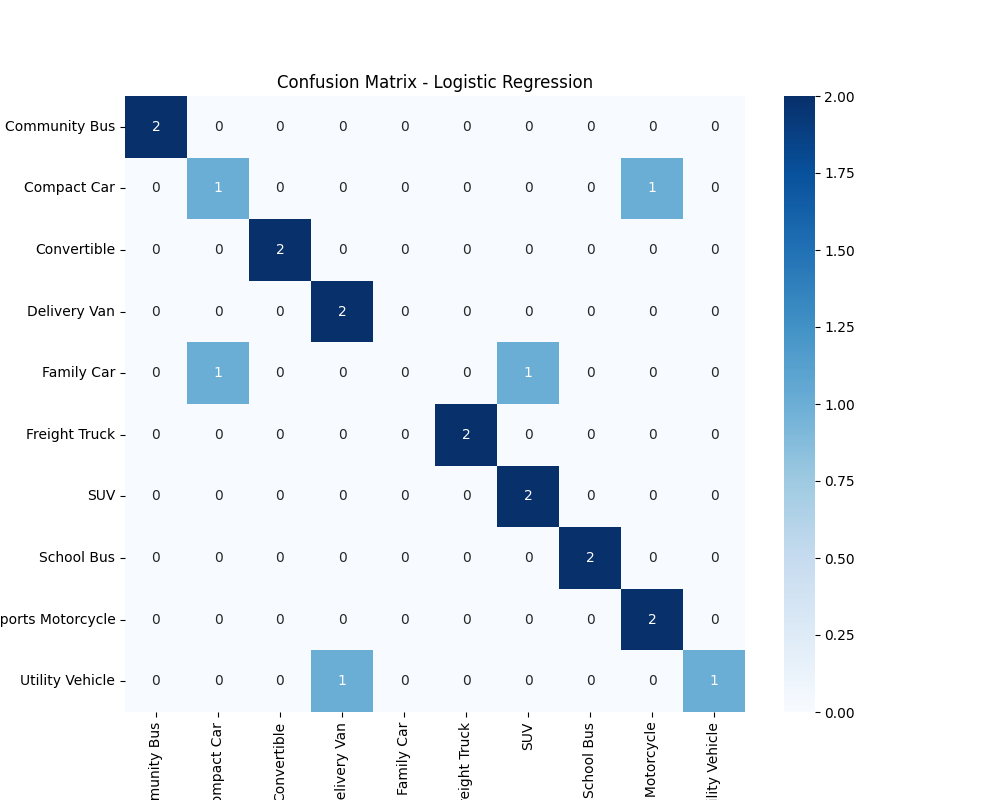

In [13]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [14]:
# Classification Report
print(f"\n{best_name} Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Logistic Regression Classification Report:
                   precision    recall  f1-score   support

    Community Bus       1.00      1.00      1.00         2
      Compact Car       0.50      0.50      0.50         2
      Convertible       1.00      1.00      1.00         2
     Delivery Van       0.67      1.00      0.80         2
       Family Car       0.00      0.00      0.00         2
    Freight Truck       1.00      1.00      1.00         2
              SUV       0.67      1.00      0.80         2
       School Bus       1.00      1.00      1.00         2
Sports Motorcycle       0.67      1.00      0.80         2
  Utility Vehicle       1.00      0.50      0.67         2

         accuracy                           0.80        20
        macro avg       0.75      0.80      0.76        20
     weighted avg       0.75      0.80      0.76        20



### 8. Dimensionality Reduction Visualization (PCA + t-SNE)

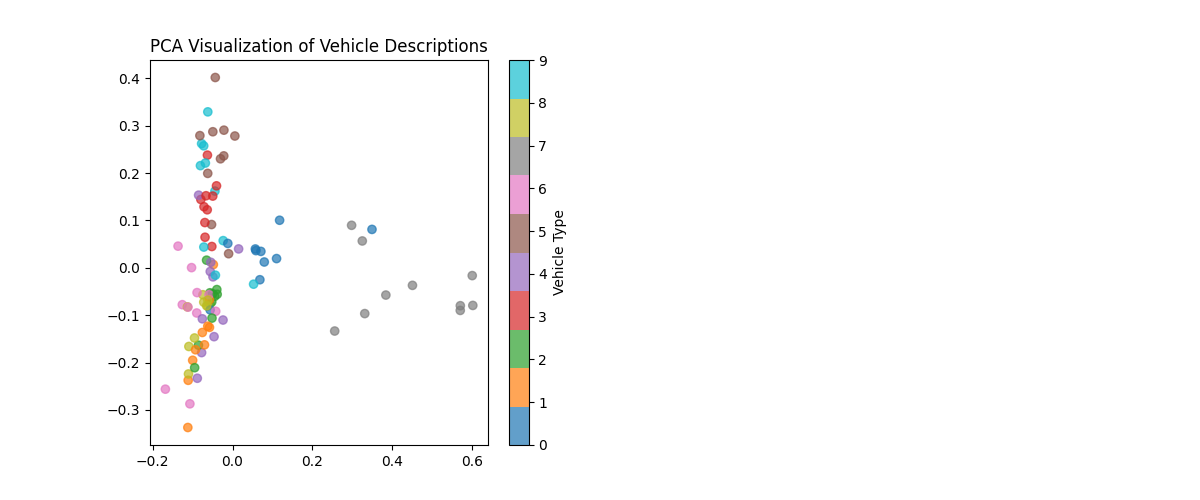

In [15]:
# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('PCA Visualization of Vehicle Descriptions')
plt.colorbar(scatter, ticks=range(len(class_names)), label='Vehicle Type')

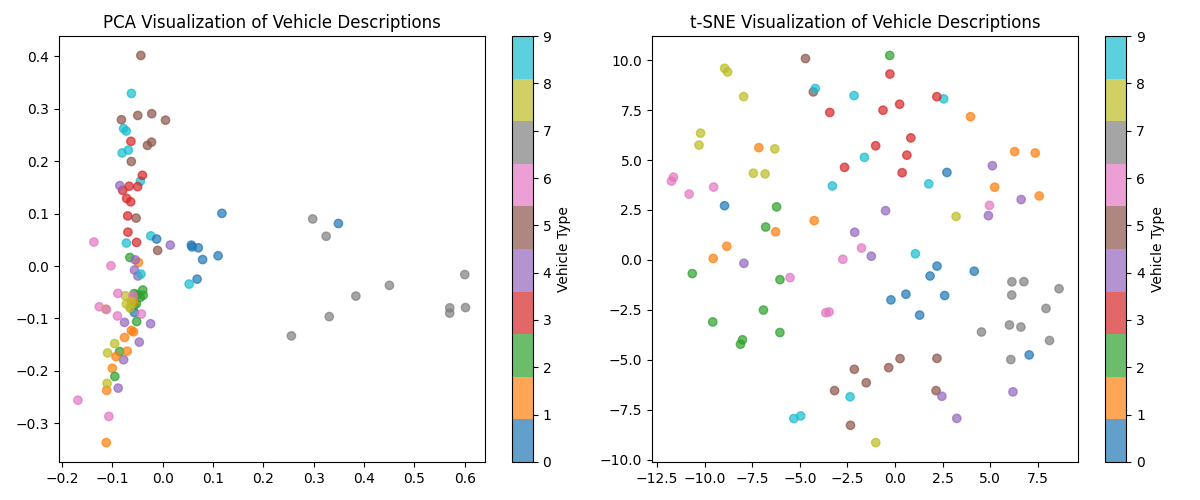

In [16]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('t-SNE Visualization of Vehicle Descriptions')
plt.colorbar(scatter2, ticks=range(len(class_names)), label='Vehicle Type')
plt.tight_layout()
plt.show()

### 9. Bokeh 3D Surface Plot (Predictions)

In [19]:
# Create 3D decision surface plot with Bokeh for algorithm predictions
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, LinearColorMapper

# Generate prediction surface for top 2 features using X_train to match y_train shapes
if hasattr(X_train, "to_numpy"):
    X_train_top2 = X_train.to_numpy()[:, :2]
else:
    X_train_top2 = X_train[:, :2]

best_model.fit(X_train_top2, y_train)

# Create meshgrid using training data bounds
x_min, x_max = X_train_top2[:, 0].min(), X_train_top2[:, 0].max()
y_min, y_max = X_train_top2[:, 1].min(), X_train_top2[:, 1].max()

x_range = np.linspace(x_min, x_max, 30)
y_range = np.linspace(y_min, y_max, 30)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
z_values = best_model.predict(grid_points).reshape(xx.shape)

# Prepare data coordinates for Bokeh image plotting
x_coords = np.arange(xx.shape[1])
y_coords = np.arange(xx.shape[0])

# Create surface plot
p = figure(
    title=f"{best_name} Decision Surface (Top 2 Features)",
    x_axis_label='Feature 1',
    y_axis_label='Feature 2',
    width=600,
    height=500
)

p.image(
    image=[z_values.astype(float)],
    x=0,
    y=0,
    dw=len(x_coords)-1,
    dh=len(y_coords)-1,
    palette="Viridis256"
)

show(p)